# Análise exploratoria dos dados

## Exercícios

## 1. Gere amostras de distribuições de Poisson com diferentes valores de $\lambda$. Para cada amostra, calcule a média e o desvio-padrão. Em seguida, faça um gráfico da média em função do desvio-padrão. O que você observa?

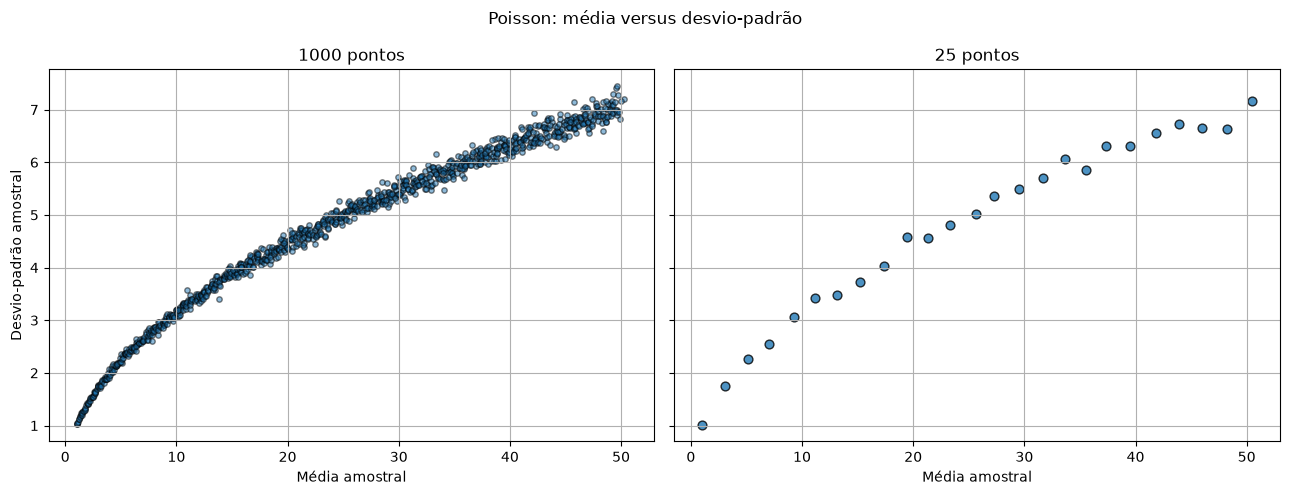

In [78]:
import numpy as np
import matplotlib.pyplot as plt

def media_desvio(n_pontos, size=1000, lamb_max=50):
    lambdas = np.linspace(1, lamb_max, n_pontos)
    medias, desvios = [], []
    for lamb in lambdas:
        amostra = np.random.poisson(lam=lamb, size=size)
        medias.append(np.mean(amostra))
        desvios.append(np.std(amostra))
    return medias, desvios

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

# Esquerda: 1000 pontos
m, d = media_desvio(1000)
axes[0].scatter(m, d, s=15, alpha=0.5, edgecolor="black")
axes[0].set_title("1000 pontos")
axes[0].set_xlabel("Média amostral")
axes[0].set_ylabel("Desvio-padrão amostral")
axes[0].grid(True)

# Direita: 25 pontos
m, d = media_desvio(25)
axes[1].scatter(m, d, s=40, alpha=0.8, edgecolor="black")
axes[1].set_title("25 pontos")
axes[1].set_xlabel("Média amostral")
axes[1].grid(True)

fig.suptitle("Poisson: média versus desvio-padrão")
plt.tight_layout()
plt.show()

O gráfico mostra que o desvio-padrão aumenta conforme a média aumenta, mas de forma não-linear.

Quando aumenta o número de pontos (testei com 1000) parece haver uma curva côncava.

## 2. Considere a base Iris. Calcule, para cada variável numérica, a média, a variância, o desvio-padrão e o intervalo interquartil.

In [79]:
import pandas as pd
import numpy as np

def estatisticas_descritivas(data):
    # média
    media = np.mean(data)
    # variância
    variancia = np.var(data)
    # DP
    desvpad = np.std(data)
    # IQR
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1

    # outputs
    print(f"A média é {media:.2f}")
    print(f"A variância é {variancia:.2f}")
    print(f"O desvio padrão é {desvpad:.2f}")
    print(f"O IQR é {iqr:.2f}")

# Lê os dados
df = pd.read_csv(r"C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\iris.csv")

# seleciona apenas as variáveis numéricas
df_num = df.select_dtypes(include=np.number)

# aplica as estatísticas para cada variável numérica
for coluna in df_num.columns:
    print(f"\n=== {coluna} ===")
    estatisticas_descritivas(df_num[coluna])


=== sepal_length ===
A média é 5.84
A variância é 0.68
O desvio padrão é 0.83
O IQR é 1.30

=== sepal_width ===
A média é 3.05
A variância é 0.19
O desvio padrão é 0.43
O IQR é 0.50

=== petal_length ===
A média é 3.76
A variância é 3.09
O desvio padrão é 1.76
O IQR é 3.50

=== petal_width ===
A média é 1.20
A variância é 0.58
O desvio padrão é 0.76
O IQR é 1.50


## 3. Obtenha o boxplot de todas as variáveis da base Iris, separando os resultados por espécie.

In [80]:
axes

array([<Axes: title={'center': '1000 pontos'}, xlabel='Média amostral', ylabel='Desvio-padrão amostral'>,
       <Axes: title={'center': '25 pontos'}, xlabel='Média amostral'>],
      dtype=object)

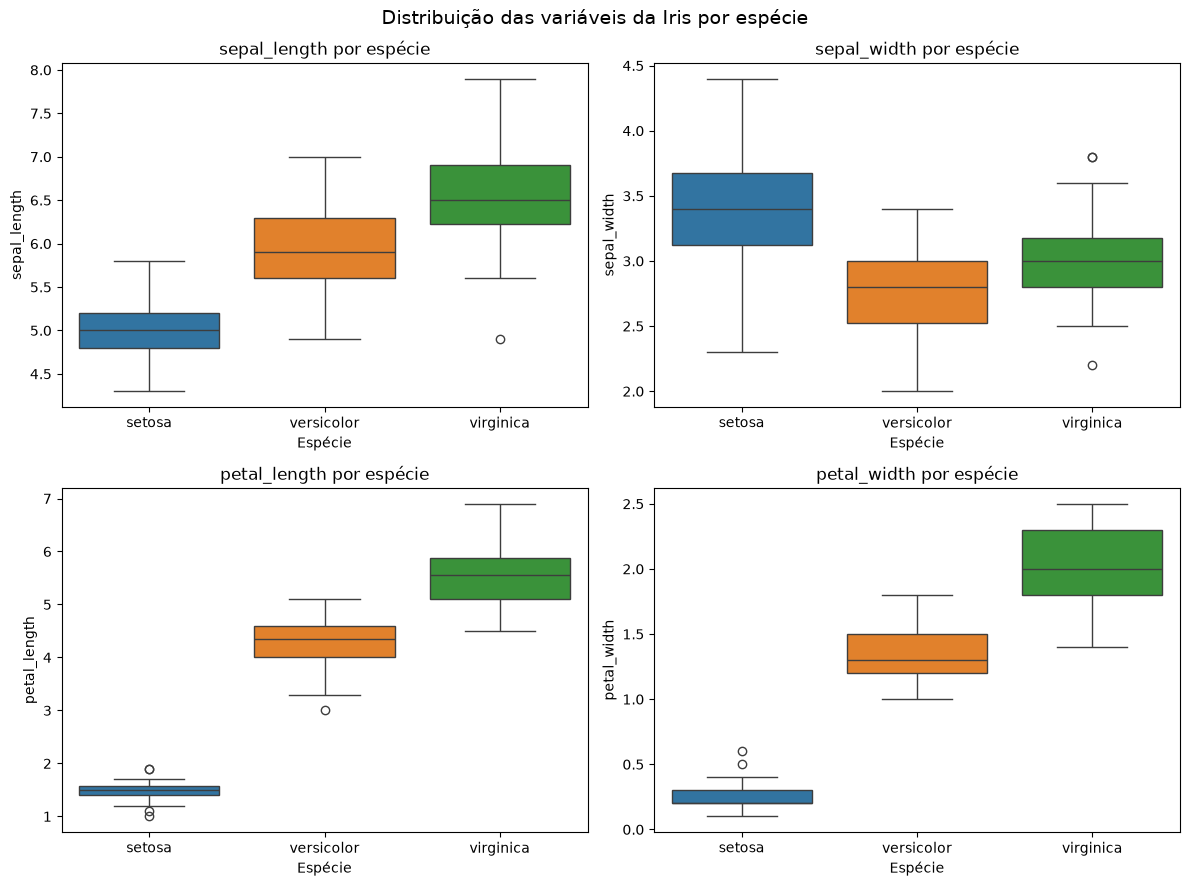

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Lê os dados
data = pd.read_csv(r"C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\iris.csv")

# variáveis numéricas a plotar
variaveis = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()  # transforma a matriz 2x2 numa lista de 4 eixos

for ax, var in zip(axes, variaveis):
    sns.boxplot(data=data, 
                x="species", 
                y=var, 
                hue="species",
                ax=ax)
    ax.set_title(f"{var} por espécie")
    ax.set_xlabel("Espécie")
    ax.set_ylabel(var)

fig.suptitle("Distribuição das variáveis da Iris por espécie", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Calcule a matriz de correlação de Pearson da base Iris. Quais pares de variáveis possuem maior correlação positiva?

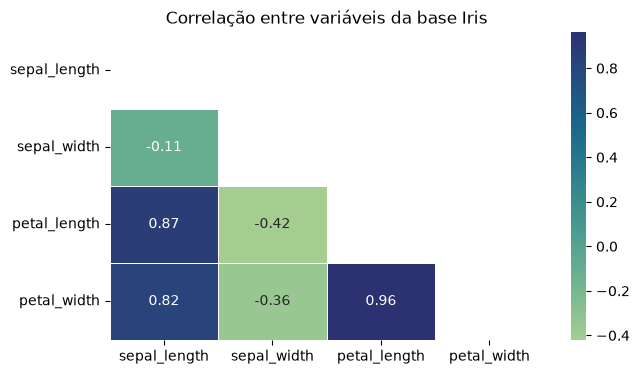

In [82]:
import seaborn as sns

df_num = df.select_dtypes(include=np.number)

# Calcula as correlações Pearson
corr = df_num.corr('pearson')

# Cria a máscara do triângulo superior
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(7, 4))

sns.heatmap(data=corr,
            mask=mask, # apresenta em forma de triangulo, evitando apresentar 2x os mesmos resultados
            annot=True,
            linewidth=.5,
            cmap=sns.color_palette("crest", as_cmap=True))

plt.title("Correlação entre variáveis da base Iris")
plt.show()


As correlações positivas mais fortes da base Iris são:

1. `petal_length × petal_width = 0,96`

2. `sepal_length × petal_length = 0,87`

3. `sepal_length × petal_width = 0,82`

## 5. Calcule a matriz de correlação de Spearman da base Iris. Os resultados são semelhantes aos obtidos com Pearson?

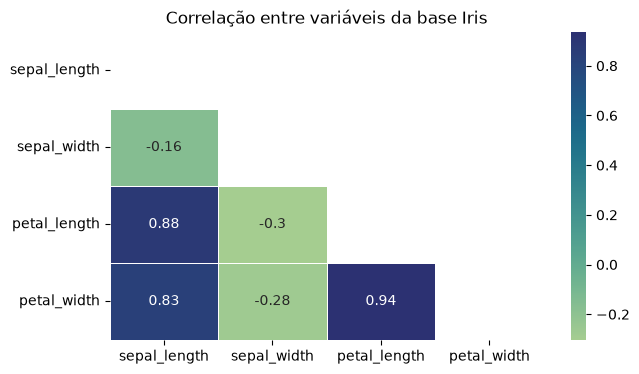

In [83]:
import seaborn as sns

df_num = df.select_dtypes(include=np.number)

# Calcula as correlações Pearson
corr = df_num.corr('spearman')

# Cria a máscara do triângulo superior
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(7, 4))

sns.heatmap(data=corr,
            mask=mask, # apresenta em forma de triangulo, evitando apresentar 2x os mesmos resultados
            annot=True,
            linewidth=.5,
            cmap=sns.color_palette("crest", as_cmap=True))

plt.title("Correlação entre variáveis da base Iris")
plt.show()

Sim, muito semelhantes!!! 

A estrutura geral é a mesma: os mesmos três pares aparecem como os mais fortes, na mesma ordem, e o sinal (positivo/negativo) de todos os pares é idêntico nos dois métodos.

## 6. Escolha uma base de dados real de seu interesse e realize uma análise exploratória inicial contendo: resumo estatístico, histogramas, boxplots e matriz de correlação.

In [84]:
import pandas as pd

url = "https://raw.githubusercontent.com/Kaymaletzki/MtCars_Dataset/main/mtcars_data.csv"

df = pd.read_csv(url)

df.head(5)

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


Caracteristicas gerais do dataset.

In [85]:
print(f"O dataset mtcars contém {df.shape[0]} linhas e {df.shape[1]} colunas")
print(80 *'-')

print("Colunas da base:")
print(df.columns)
print(80 *'-')

print("Tipos de dados:")
print(df.dtypes)
print(80 *'-')

print("Quantidade de valores ausentes por coluna:")
print(df.isna().sum())
print(80 *'-')

print("\nNúmero de linhas duplicadas:", df.duplicated().sum())

O dataset mtcars contém 32 linhas e 12 colunas
--------------------------------------------------------------------------------
Colunas da base:
Index(['model', 'mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am',
       'gear', 'carb'],
      dtype='str')
--------------------------------------------------------------------------------
Tipos de dados:
model        str
mpg      float64
cyl        int64
disp     float64
hp         int64
drat     float64
wt       float64
qsec     float64
vs         int64
am         int64
gear       int64
carb       int64
dtype: object
--------------------------------------------------------------------------------
Quantidade de valores ausentes por coluna:
model    0
mpg      0
cyl      0
disp     0
hp       0
drat     0
wt       0
qsec     0
vs       0
am       0
gear     0
carb     0
dtype: int64
--------------------------------------------------------------------------------

Número de linhas duplicadas: 0


Estatísticas descritivas

In [86]:
# Variaveis numericas
df.describe(include=np.number)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


In [87]:
# variaveis não numericas  - model
data_str = df.select_dtypes(include=str)
data_str.describe()

,model
count,32
unique,32
top,Mazda RX4
freq,1


Outro opção usando a função `skim` da biblioteca `skimpy`

In [88]:
from skimpy import skim

skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 32     │ │ int64       │ 6     │                                                          │
│ │ Number of columns │ 12     │ │ float64     │ 5     │                                                          │
│ └───────────────────┴────────┘ │ string      │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column    ┃ NA   ┃ NA %   ┃ mean      ┃ sd       ┃ p0      ┃ p25     ┃ p50     ┃ p75    ┃ p100   ┃ hist    ┃  │
│ ┡━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩  │
│ │    mpg    │    0 │      0 │     20.09 │    6.027 │    10.4 │   15.43 │    19.2 │   22.8 │   33.9 │ ▃▇▇▃▁▃  │  │
│ │    cyl    │    0 │      0 │     6.188 │    1.786 │       4 │       4 │       6 │      8 │      8 │ ▆  ▅ ▇  │  │
│ │   disp    │    0 │      0 │     230.7 │    123.9 │    71.1 │   120.8 │   196.3 │    326 │    472 │ ▇▆▂▅▅▃  │  │
│ │    hp     │    0 │      0 │     146.7 │    68.56 │      52 │    96.5 │     123 │    180 │    335 │ ▇▇▇▃▃▁  │  │
│ │   drat    │    0 │      0 │     3.597 │   0.5347 │    2.76 │    3.08 │   3.695 │   3.92 │   4.93 │ ▇▃▅▇▃▁  │  │
│ │    wt     │    0 │      0 │     3.217 │   0.9785 │   1.513 │   2.581 │   3.325 │   3.61 │  5.424 │ ▅▅▇▆ ▂  │  │
│ │   qsec    │    0 │      0 │     17.85 │    1.787 │    14.5 │   16.89 │   17.71 │   18.9 │   22.9 │ ▃▅▇▅▁▁  │  │
│ │    vs     │    0 │      0 │    0.4375 │    0.504 │       0 │       0 │       0 │      1 │      1 │ ▇    ▆  │  │
│ │    am     │    0 │      0 │    0.4062 │    0.499 │       0 │       0 │       0 │      1 │      1 │ ▇    ▅  │  │
│ │   gear    │    0 │      0 │     3.688 │   0.7378 │       3 │       3 │       4 │      4 │      5 │ ▇  ▆ ▃  │  │
│ │   carb    │    0 │      0 │     2.812 │    1.615 │       1 │       2 │       2 │      4 │      8 │   ▇▁▅   │  │
│ └───────────┴──────┴────────┴───────────┴──────────┴─────────┴─────────┴─────────┴────────┴────────┴─────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┓  │
│ ┃        ┃    ┃      ┃          ┃            ┃            ┃            ┃ chars per  ┃ words per  ┃ total     ┃  │
│ ┃ column ┃ NA ┃ NA % ┃ shortest ┃ longest    ┃ min        ┃ max        ┃ row        ┃ row        ┃ words     ┃  │
│ ┡━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━┩  │
│ │ model  │  0 │    0 │ Valiant  │  Lincoln   │    AMC     │ Volvo 142E │       11.9 │        2.1 │        66 │  │
│ │        │    │      │          │ Continenta │  Javelin   │            │            │            │           │  │
│ │        │    │      │          │     l      │            │            │            │            │           │  │
│ └────────┴────┴──────┴──────────┴────────────┴────────────┴────────────┴────────────┴────────────┴───────────┘  │
╰────────────────────────────────────────────────────── 

Histogramas

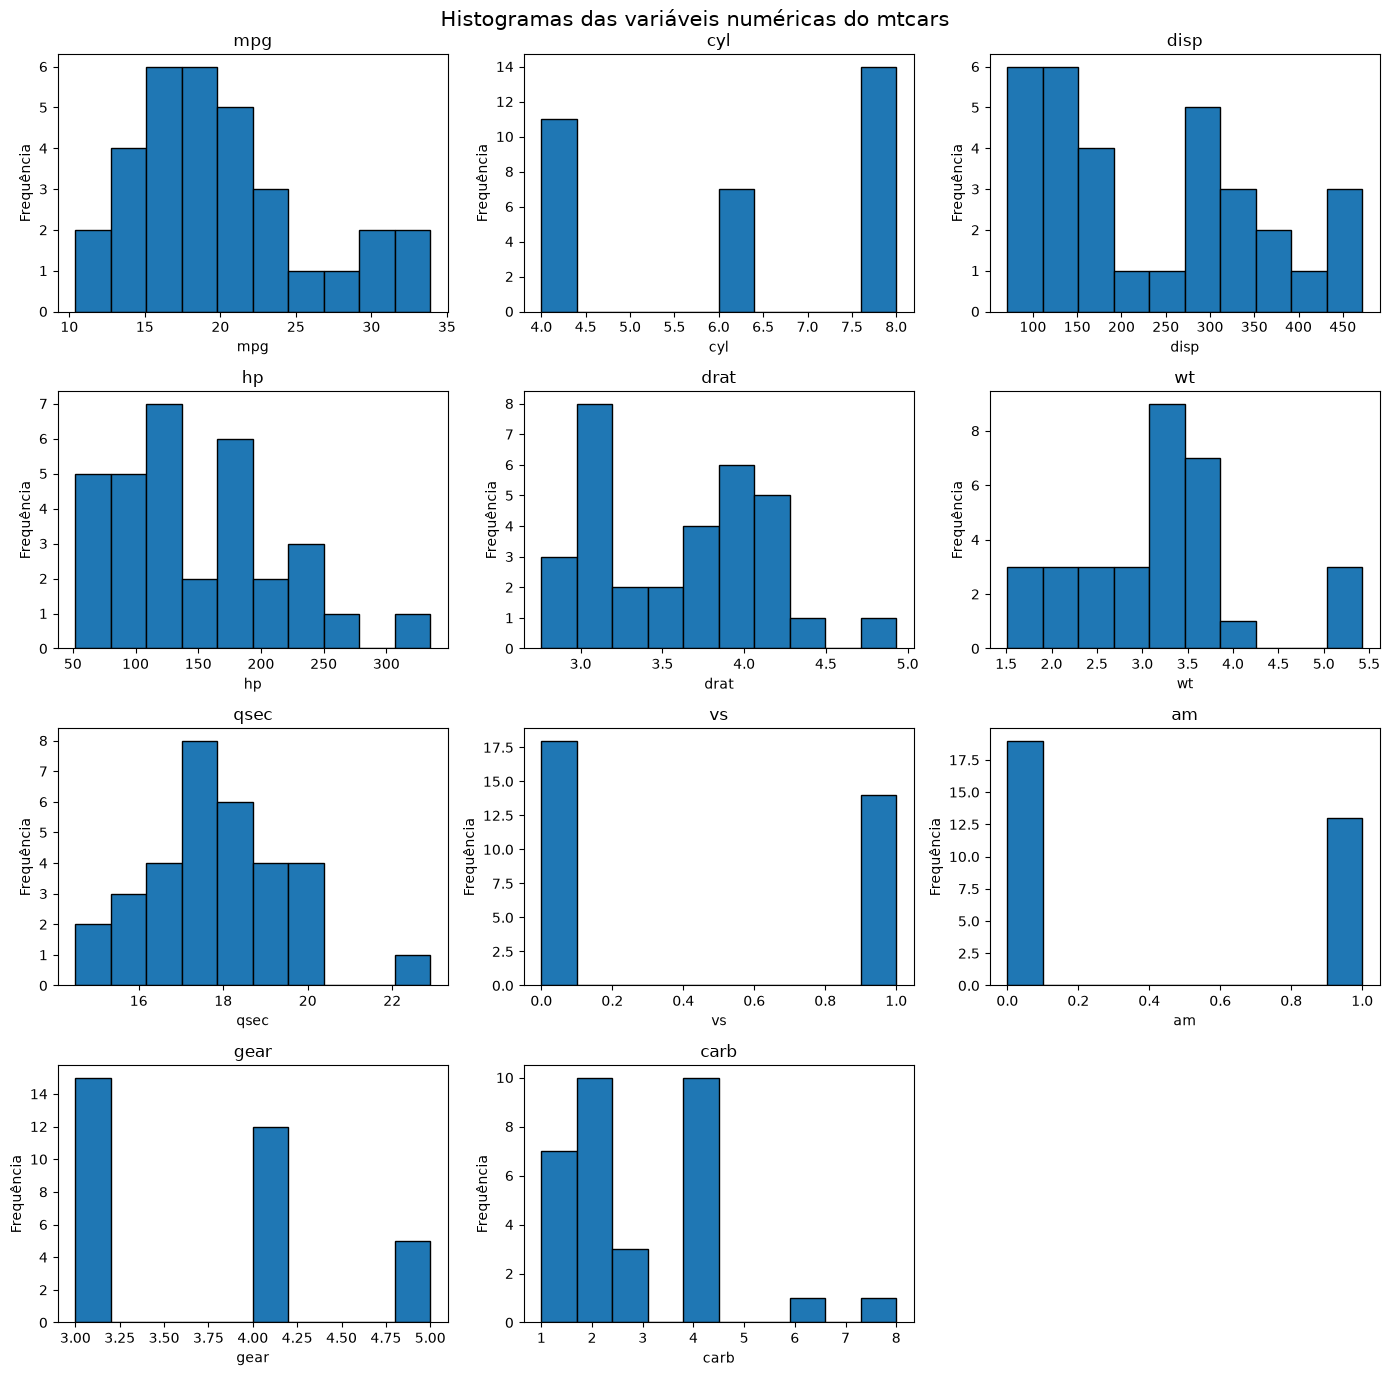

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

# seleciona as variáveis numéricas
import numpy as np
df_num = df.select_dtypes(include=np.number)

fig, axes = plt.subplots(4, 3, figsize=(14, 14))
axes = axes.flatten()  # transforma a grade 4x3 numa lista de 12 eixos

for ax, coluna in zip(axes, df_num.columns):
    ax.hist(df_num[coluna], bins=10, edgecolor="black")
    ax.set_title(coluna)
    ax.set_xlabel(coluna)
    ax.set_ylabel("Frequência")

# esconde os painéis que sobraram (12 eixos, 11 variáveis)
for ax in axes[len(df_num.columns):]:
    ax.set_visible(False)

fig.suptitle("Histogramas das variáveis numéricas do mtcars", fontsize=15)
plt.tight_layout()
plt.show()

Boxplots

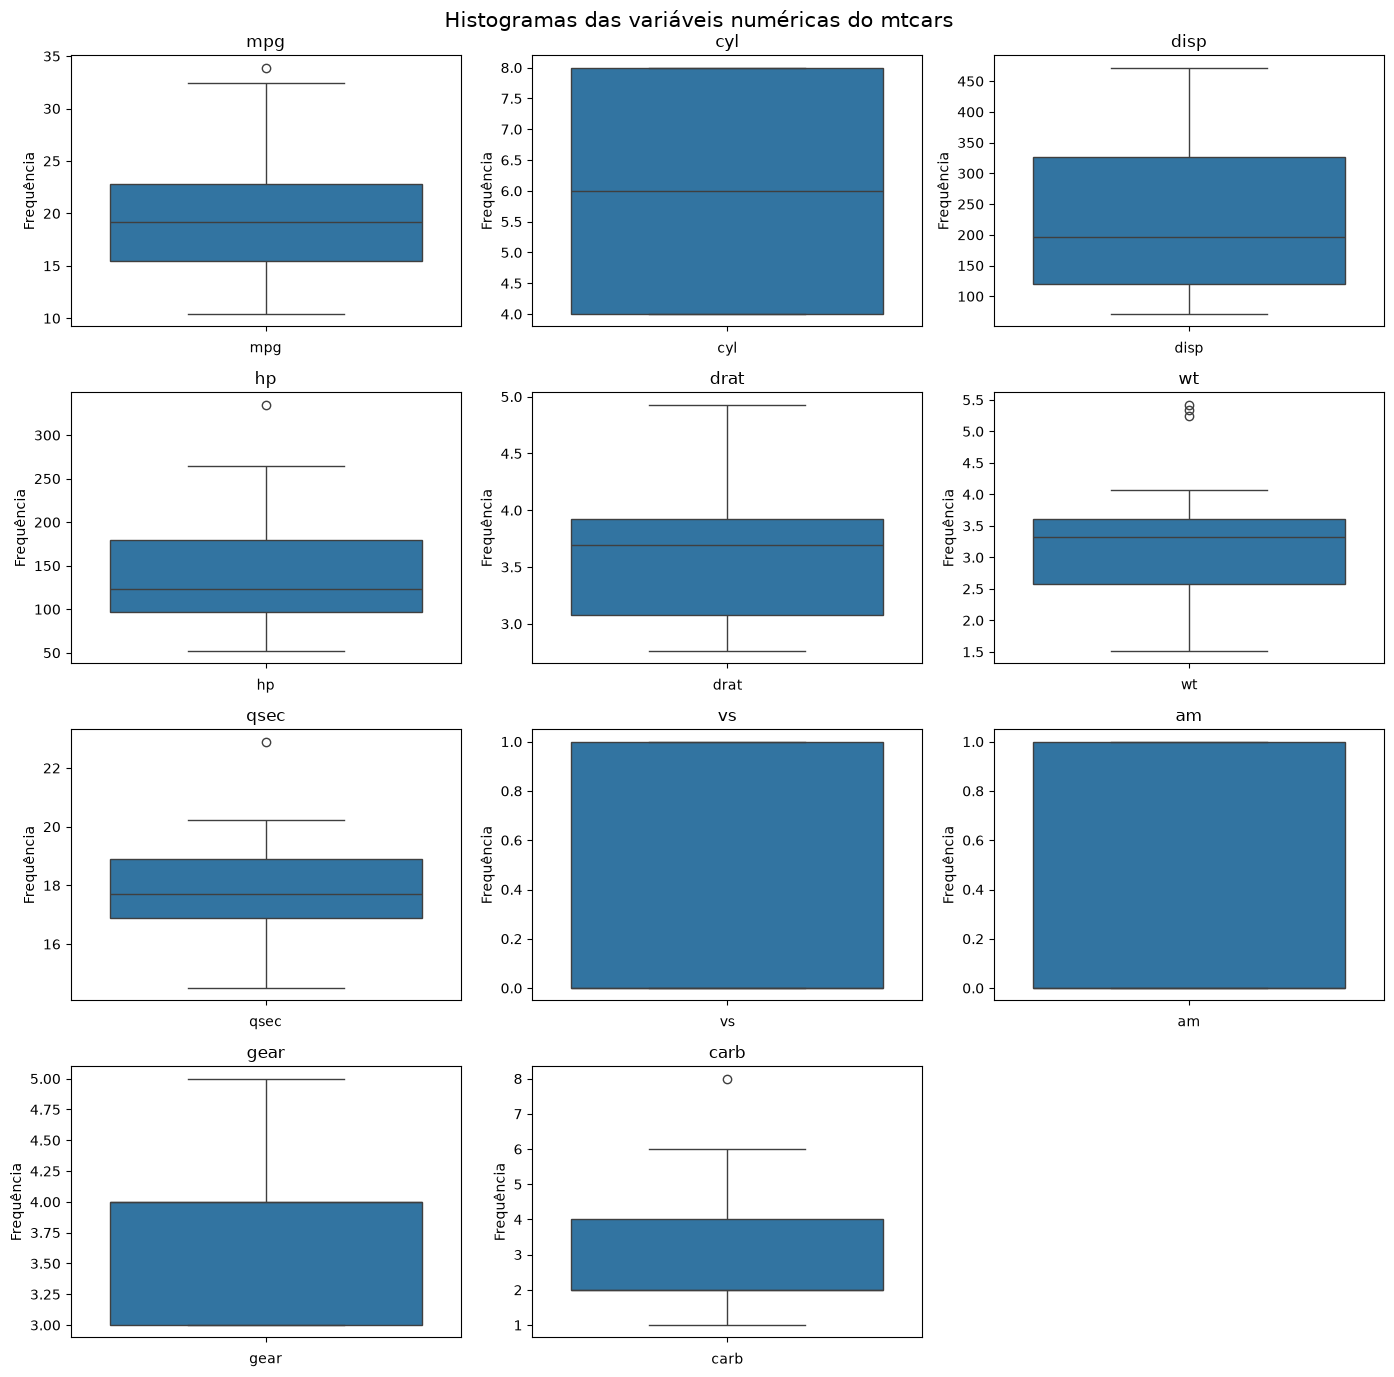

In [90]:
import pandas as pd
import matplotlib.pyplot as plt

# seleciona as variáveis numéricas
import numpy as np
df_num = df.select_dtypes(include=np.number)

fig, axes = plt.subplots(4, 3, figsize=(14, 14))
axes = axes.flatten()  # transforma a grade 4x3 numa lista de 12 eixos

for ax, coluna in zip(axes, df_num.columns):
    sns.boxplot(y=df_num[coluna], ax=ax)
    ax.set_title(coluna)
    ax.set_xlabel(coluna)
    ax.set_ylabel("Frequência")

# esconde os painéis que sobraram (12 eixos, 11 variáveis)
for ax in axes[len(df_num.columns):]:
    ax.set_visible(False)

fig.suptitle("Histogramas das variáveis numéricas do mtcars", fontsize=15)
plt.tight_layout()
plt.show()

Correlações

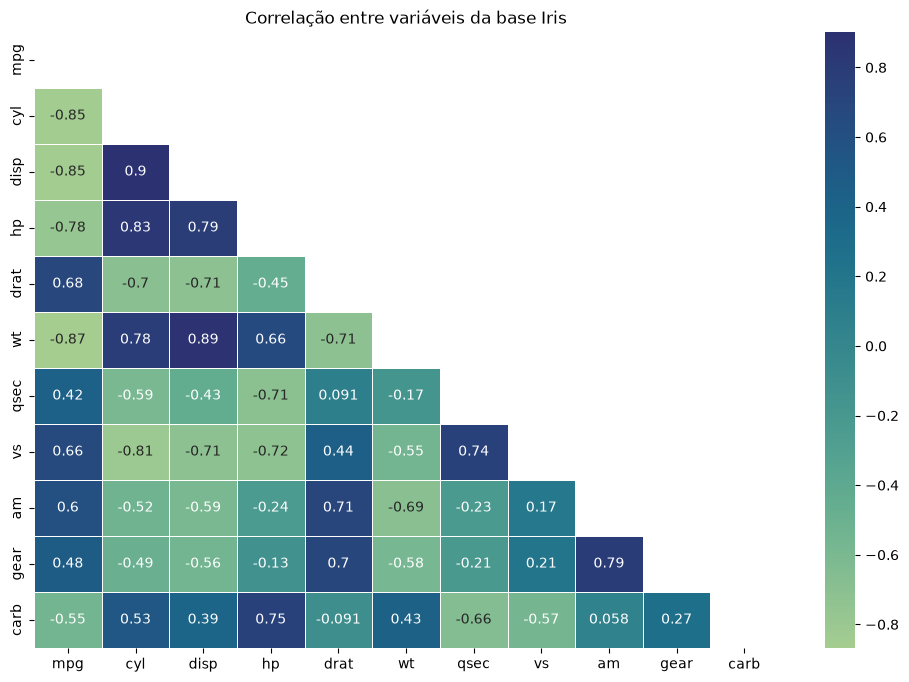

In [91]:
# Calcula as correlações Pearson
corr = df_num.corr('pearson')

# Cria a máscara do triângulo superior
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))

sns.heatmap(data=corr,
            mask=mask, # apresenta em forma de triangulo, evitando apresentar 2x os mesmos resultados
            annot=True,
            linewidth=.5,
            cmap=sns.color_palette("crest", as_cmap=True))

plt.title("Correlação entre variáveis da base Iris")
plt.show()

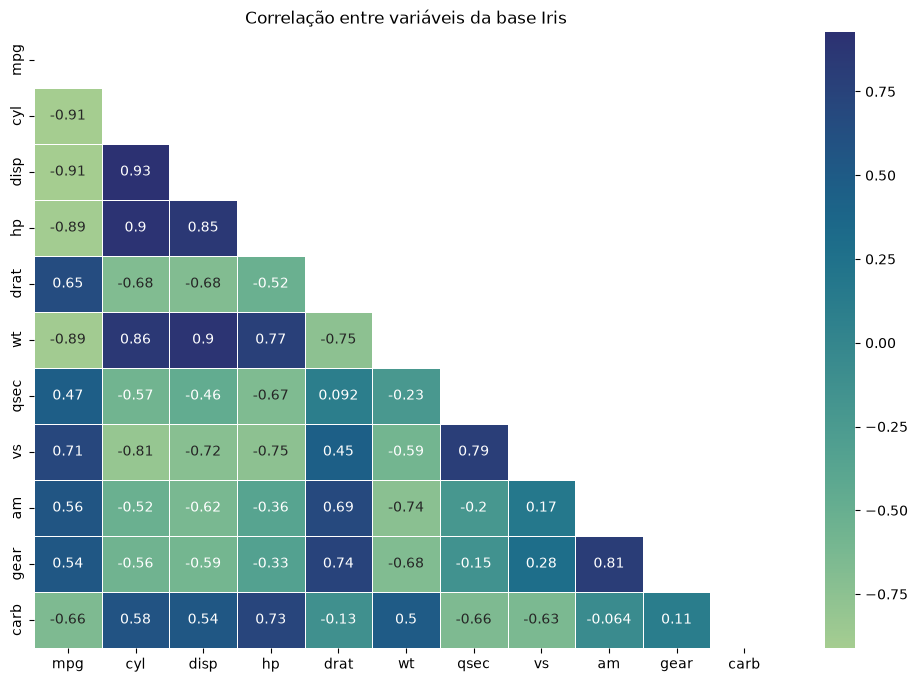

In [92]:
# Calcula as correlações Pearson
corr = df_num.corr('spearman')

# Cria a máscara do triângulo superior
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))

sns.heatmap(data=corr,
            mask=mask, # apresenta em forma de triangulo, evitando apresentar 2x os mesmos resultados
            annot=True,
            linewidth=.5,
            cmap=sns.color_palette("crest", as_cmap=True))

plt.title("Correlação entre variáveis da base Iris")
plt.show()

Finalizado!

Saulo Gil

😉